# Passo 2 — Exploração e Preparação dos Dados
**Dataset:** Brasileirão Série A (Transfermarkt)  
**Objetivo:** Entender a estrutura geral, tipos de dados, valores ausentes e distribuições.

## 1. Carregamento

In [1]:
import pandas as pd

CAMINHO_CSV = r'C:\Users\bruno\Downloads\mundo_transfermarkt_competicoes_brasileirao_serie_a.csv\mundo_transfermarkt_competicoes_brasileirao_serie_a.csv'

df = pd.read_csv(CAMINHO_CSV)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (8453, 35)


,ano_campeonato,data,rodada,estadio,arbitro,publico,publico_max,time_mandante,time_visitante,tecnico_mandante,...,chutes_bola_parada_mandante,chutes_bola_parada_visitante,defesas_mandante,defesas_visitante,impedimentos_mandante,impedimentos_visitante,chutes_mandante,chutes_visitante,chutes_fora_mandante,chutes_fora_visitante
0,2005,2005-10-08,31,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,Fluminense,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005,2005-04-23,1,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,Goiás EC,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005,2005-08-21,21,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,Vasco da Gama,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Estrutura e Tipos

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8453 entries, 0 to 8452
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ano_campeonato                  8453 non-null   int64  
 1   data                            8453 non-null   str    
 2   rodada                          8453 non-null   int64  
 3   estadio                         8442 non-null   str    
 4   arbitro                         6743 non-null   str    
 5   publico                         6742 non-null   float64
 6   publico_max                     4181 non-null   float64
 7   time_mandante                   8453 non-null   str    
 8   time_visitante                  8453 non-null   str    
 9   tecnico_mandante                6299 non-null   str    
 10  tecnico_visitante               6299 non-null   str    
 11  colocacao_mandante              6743 non-null   float64
 12  colocacao_visitante             6743 non-null

## 3. Valores Ausentes por Coluna

In [3]:
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(1)
resumo_nulos = pd.DataFrame({'nulos': nulos, 'pct_%': pct})
resumo_nulos[resumo_nulos['nulos'] > 0].sort_values('pct_%', ascending=False)

,nulos,pct_%
chutes_fora_visitante,6366,75.3
chutes_fora_mandante,6366,75.3
impedimentos_visitante,6366,75.3
impedimentos_mandante,6366,75.3
chutes_visitante,6366,75.3
chutes_mandante,6366,75.3
defesas_mandante,6366,75.3
defesas_visitante,6366,75.3
chutes_bola_parada_visitante,6366,75.3
chutes_bola_parada_mandante,6366,75.3


## 4. Nulos por Ano — entender se são estruturais

In [4]:
colunas_checar = ['arbitro', 'tecnico_mandante', 'valor_equipe_titular_mandante', 'chutes_mandante']

por_ano = df.groupby('ano_campeonato')[colunas_checar].apply(lambda g: g.isnull().sum())
por_ano['total_partidas'] = df.groupby('ano_campeonato').size()
por_ano

,arbitro,tecnico_mandante,valor_equipe_titular_mandante,chutes_mandante,total_partidas
ano_campeonato,,,,,
2003,456,456,456,456,456
2004,456,456,456,456,456
2005,418,418,418,418,418
2006,380,380,380,380,380
2007,0,92,92,380,380
2008,0,4,4,380,380
2009,0,40,40,380,380
2010,0,45,45,380,380
2011,0,71,71,380,380


## 5. Estatísticas Descritivas — colunas numéricas

In [5]:
df.describe()

,ano_campeonato,rodada,publico,publico_max,colocacao_mandante,colocacao_visitante,valor_equipe_titular_mandante,valor_equipe_titular_visitante,idade_media_titular_mandante,idade_media_titular_visitante,...,chutes_bola_parada_mandante,chutes_bola_parada_visitante,defesas_mandante,defesas_visitante,impedimentos_mandante,impedimentos_visitante,chutes_mandante,chutes_visitante,chutes_fora_mandante,chutes_fora_visitante
count,8453.000000,8453.000000,6742.000000,4181.000000,6743.000000,6743.000000,6.355000e+03,6.355000e+03,6353.000000,6353.000000,...,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.00000,2087.000000,2087.000000,2087.000000,2087.000000
mean,2013.161481,19.386490,16189.951943,43910.461373,10.617084,10.384992,1.615418e+07,1.575332e+07,27.309869,27.211727,...,13.724964,14.068999,2.834691,3.544322,1.514135,1.42597,13.151893,10.256828,6.022520,4.650695
std,6.368650,10.924158,14074.412391,19838.986238,5.761853,5.770435,1.471446e+07,1.410733e+07,1.619763,1.655798,...,4.406922,4.390899,1.869671,2.151016,1.417487,1.33043,6.095550,5.245020,2.849193,2.538709
min,2003.000000,1.000000,0.000000,5000.000000,1.000000,1.000000,5.600000e+02,4.430000e+02,20.400000,20.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,2008.000000,10.000000,5898.250000,24584.000000,6.000000,5.000000,5.850000e+06,5.800000e+06,26.200000,26.100000,...,11.000000,11.000000,1.000000,2.000000,0.000000,0.00000,9.000000,6.000000,4.000000,3.000000
50%,2013.000000,19.000000,12685.500000,43600.000000,11.000000,10.000000,1.170000e+07,1.165000e+07,27.300000,27.200000,...,13.000000,14.000000,3.000000,3.000000,1.000000,1.00000,13.000000,10.000000,6.000000,4.000000
75%,2019.000000,29.000000,22963.250000,57483.000000,16.000000,15.000000,2.360000e+07,2.300000e+07,28.400000,28.300000,...,16.000000,17.000000,4.000000,5.000000,2.000000,2.00000,17.000000,14.000000,8.000000,6.000000
max,2024.000000,38.000000,82044.000000,87101.000000,20.000000,20.000000,1.005000e+08,9.600000e+07,33.600000,33.100000,...,30.000000,30.000000,12.000000,13.000000,9.000000,8.00000,37.000000,31.000000,21.000000,14.000000


## 6. Valores Únicos — colunas categóricas

In [7]:
cols_cat = ['ano_campeonato', 'time_mandante', 'time_visitante', 'estadio', 'arbitro']

for col in cols_cat:
    print(f'{col}: {df[col].nunique()} valores únicos')

ano_campeonato: 22 valores únicos
time_mandante: 47 valores únicos
time_visitante: 47 valores únicos
estadio: 84 valores únicos
arbitro: 209 valores únicos


## 7. Times presentes no dataset

In [8]:
todos_times = pd.concat([df['time_mandante'], df['time_visitante']]).unique()
todos_times_sorted = sorted(todos_times)
print(f'Total de times distintos: {len(todos_times_sorted)}')
print(todos_times_sorted)

Total de times distintos: 47
['América-MG', 'América-RN', 'Athletico-PR', 'Atlético-GO', 'Atlético-MG', 'Atlético-PR', 'Avaí FC', 'Barueri', 'Botafogo', 'Brasiliense-DF', 'CSA', 'Ceará SC', 'Chapecoense', 'Corinthians', 'Coritiba FC', 'Criciúma EC', 'Cruzeiro', 'Cuiabá-MT', 'EC Bahia', 'EC Vitória', 'Figueirense FC', 'Flamengo', 'Fluminense', 'Fortaleza', 'Goiás', 'Goiás EC', 'Grêmio', 'Guarani', 'Internacional', 'Ipatinga FC', 'Joinville-SC', 'Juventude', 'Náutico', 'Palmeiras', 'Paraná', 'Paysandu SC', 'Ponte Preta', 'Portuguesa', 'RB Bragantino', 'Santa Cruz', 'Santo André', 'Santos', 'Santos FC', 'Sport Recife', 'São Caetano', 'São Paulo', 'Vasco da Gama']


## 8. Verificar inconsistências — partida com placar nulo

In [9]:
df[df['gols_mandante'].isnull() | df['gols_visitante'].isnull()]

,ano_campeonato,data,rodada,estadio,arbitro,publico,publico_max,time_mandante,time_visitante,tecnico_mandante,...,chutes_bola_parada_mandante,chutes_bola_parada_visitante,defesas_mandante,defesas_visitante,impedimentos_mandante,impedimentos_visitante,chutes_mandante,chutes_visitante,chutes_fora_mandante,chutes_fora_visitante
423,2016,2016-12-11,38,Arena Condá,Rodrigo D'Alonso Ferreira,NaN,22600.0,Chapecoense,Atlético-MG,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 9. Converter tipos

In [10]:
df['data'] = pd.to_datetime(df['data'])
df['ano_campeonato'] = df['ano_campeonato'].astype(int)

# Colunas inteiras que vieram como float por conta dos NaNs
cols_int = ['rodada', 'publico', 'publico_max', 'gols_mandante', 'gols_visitante',
            'gols_1_tempo_mandante', 'gols_1_tempo_visitante',
            'escanteios_mandante', 'escanteios_visitante',
            'faltas_mandante', 'faltas_visitante',
            'chutes_mandante', 'chutes_visitante', 'chutes_fora_mandante', 'chutes_fora_visitante',
            'chutes_bola_parada_mandante', 'chutes_bola_parada_visitante',
            'defesas_mandante', 'defesas_visitante',
            'impedimentos_mandante', 'impedimentos_visitante']

for col in cols_int:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dtypes

ano_campeonato                             int64
data                              datetime64[us]
rodada                                     int64
estadio                                      str
arbitro                                      str
publico                                  float64
publico_max                              float64
time_mandante                                str
time_visitante                               str
tecnico_mandante                             str
tecnico_visitante                            str
colocacao_mandante                       float64
colocacao_visitante                      float64
valor_equipe_titular_mandante            float64
valor_equipe_titular_visitante           float64
idade_media_titular_mandante             float64
idade_media_titular_visitante            float64
gols_mandante                            float64
gols_visitante                           float64
gols_1_tempo_mandante                    float64
gols_1_tempo_visitan

## 10. Distribuição de gols por partida

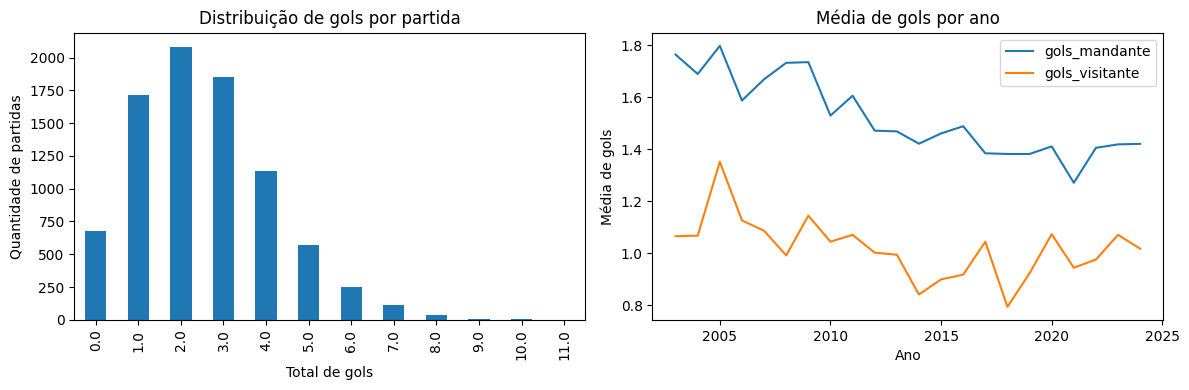

In [11]:
import matplotlib.pyplot as plt

df['total_gols'] = df['gols_mandante'] + df['gols_visitante']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['total_gols'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribuição de gols por partida')
axes[0].set_xlabel('Total de gols')
axes[0].set_ylabel('Quantidade de partidas')

df.groupby('ano_campeonato')[['gols_mandante', 'gols_visitante']].mean().plot(ax=axes[1])
axes[1].set_title('Média de gols por ano')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Média de gols')

plt.tight_layout()
plt.savefig('../../Aprendizado/grafico_gols_exploracao.png', dpi=100)
plt.show()

## 11. Salvar DataFrame limpo

In [12]:
df.to_csv('../../Aprendizado/brasileirao_limpo.csv', index=False)
print(f'Arquivo salvo: {len(df)} linhas, {len(df.columns)} colunas')

Arquivo salvo: 8453 linhas, 36 colunas
